In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pylab
import scipy.stats as stats


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
#Data seed 
np.random.seed(200728)

In [3]:
diabetes = pd.read_csv("./diabetes.csv")

In [4]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Rename columns to lowercase
diabetes. rename (columns={column: column.lower() for column in diabetes.columns.values}, inplace=True)
diabetes.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
diabetes.describe()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


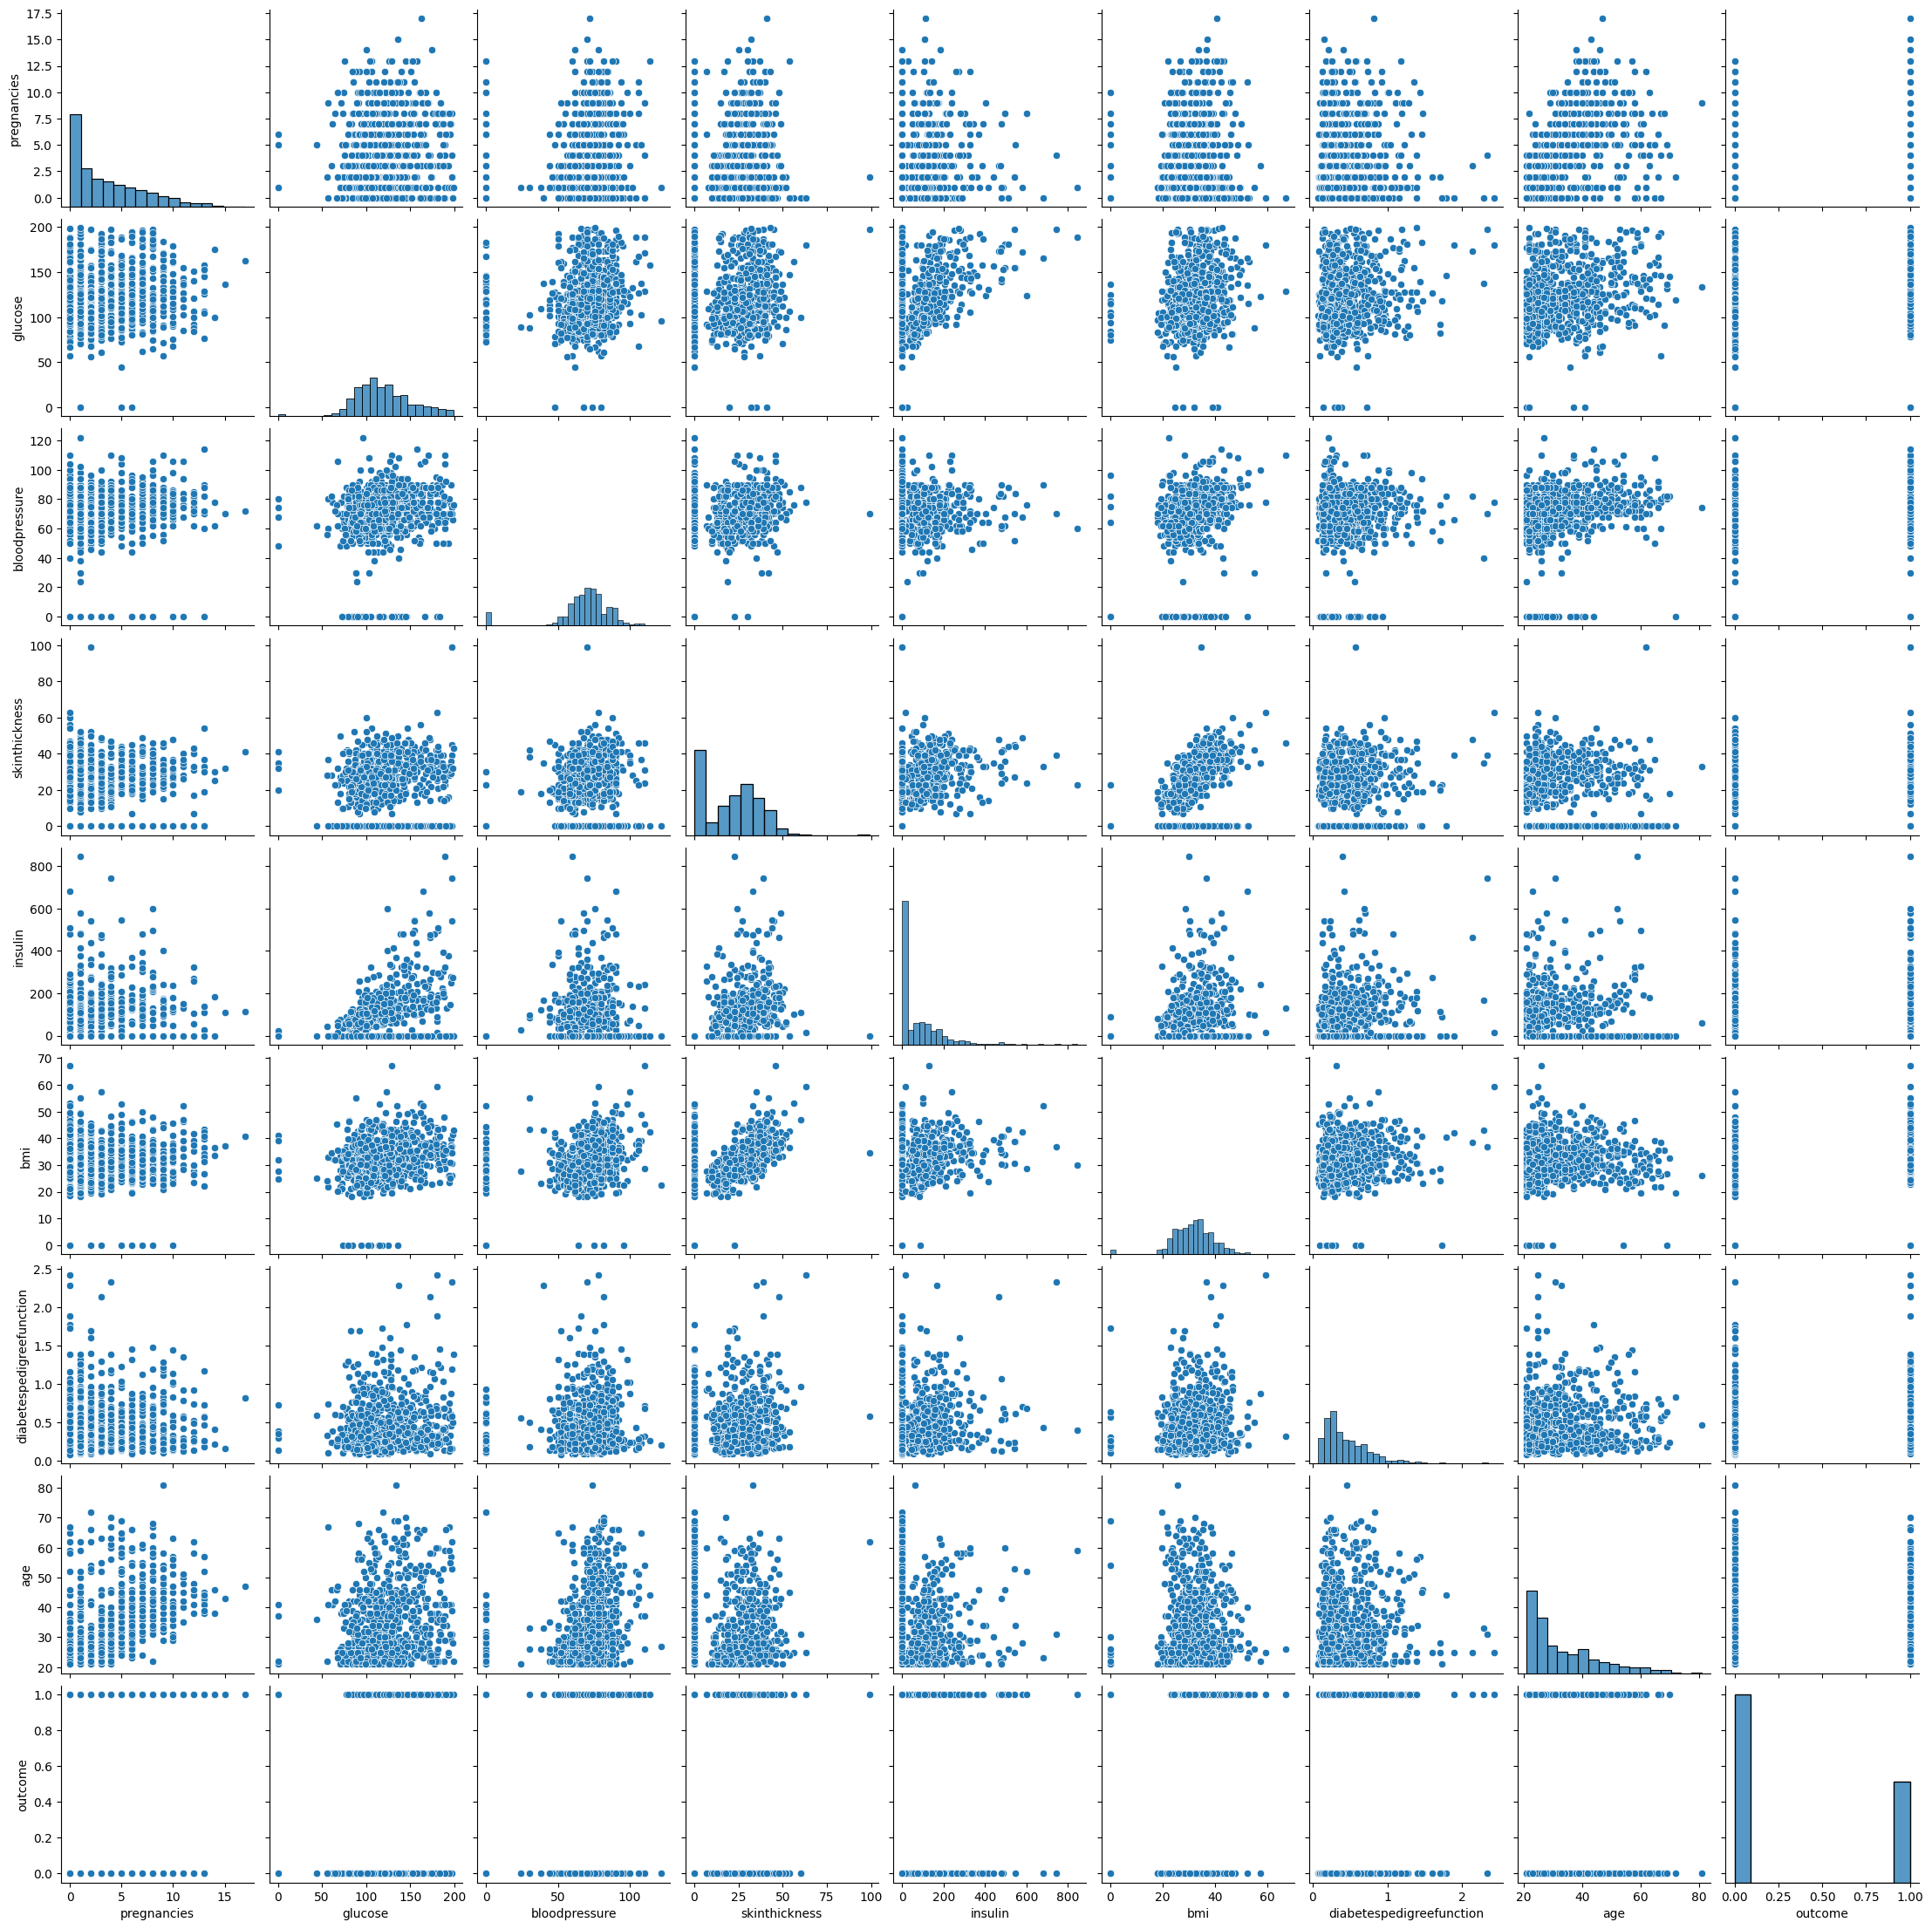

In [7]:
#predicción: gloucose
#la grafica funciona para ver la relación entre las variables, 
# pero no es tan clara, por lo que se puede usar un mapa de calor para ver la correlación entre las variables
sns.pairplot(diabetes)

In [8]:
diabetes.columns.values

array(['pregnancies', 'glucose', 'bloodpressure', 'skinthickness',
       'insulin', 'bmi', 'diabetespedigreefunction', 'age', 'outcome'],
      dtype=object)

In [9]:
X = diabetes [['bmi']]
y = diabetes [['glucose']]

In [10]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

In [11]:
print(x_train.shape, y_train.shape)


(537, 1) (537, 1)


In [12]:
print(x_test.shape, y_test.shape)

(231, 1) (231, 1)


# Training

In [13]:
lr = LinearRegression()

In [ ]:
#entrenar el modelo
m_lr= lr.fit(x_train, y_train)

Obtener las betas de las variables

In [16]:
m_lr.coef_

array([[0.88262361]])

In [17]:
m_lr.intercept_

array([92.68416999])

In [18]:
predictions = m_lr.predict(x_test)

In [23]:
predictions[:5]

array([[123.48773384],
       [111.30752808],
       [118.80982873],
       [127.81258951],
       [124.54688217]])

Metricas de desempeño

In [20]:
mean_absolute_error(y_test, predictions)

24.45332477793409

In [26]:
xxx= mean_squared_error(y_test, predictions)
print(f"rmse: {np.sqrt(xxx)}")


rmse: 30.88959746514379


Residuales

In [27]:
residuals = y_test - predictions

In [28]:
residuals.shape

(231, 1)

In [29]:
residuals.head()

,glucose
373,-18.487734
134,-15.307528
711,7.190171
705,-47.812590
289,-16.546882


In [30]:
a= predictions.reshape(residuals.shape[0],)

In [31]:
a[:4]

array([123.48773384, 111.30752808, 118.80982873, 127.81258951])

In [33]:
df_residuals = pd.DataFrame({'y_test': y_test['glucose'], 'predictions': a, 
                             'residuals': residuals['glucose']})

<Axes: xlabel='predictions', ylabel='residuals'>

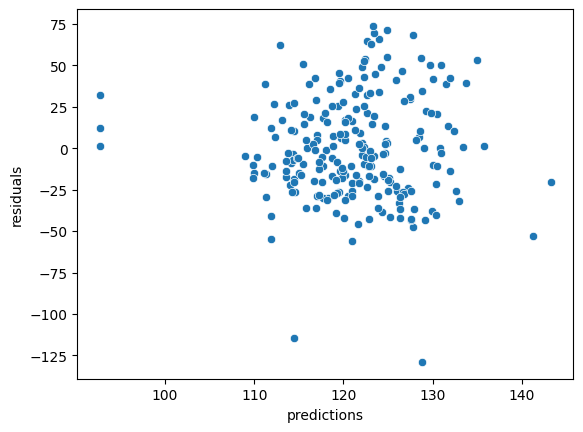

In [34]:
sns.scatterplot(x='predictions', y='residuals', data=df_residuals)

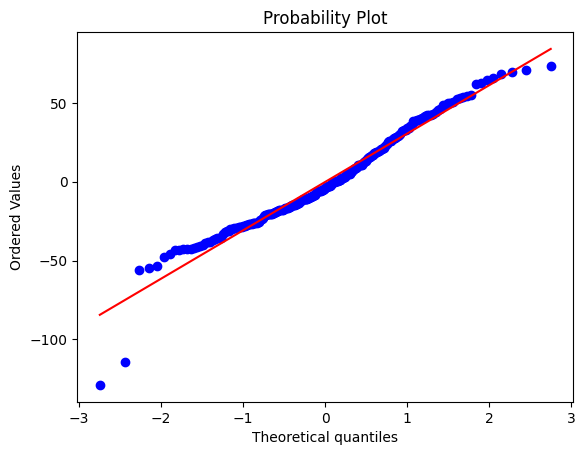

In [35]:
stats.probplot(df_residuals['residuals'], dist="norm", plot=pylab)
pylab.show()

In [36]:
residuals.head()

,glucose
373,-18.487734
134,-15.307528
711,7.190171
705,-47.812590
289,-16.546882
